In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [9]:
#  add light grid to adll figs
plt.rcParams.update({
        "text.usetex": False,          # disable system LaTeX
        "mathtext.fontset": "stix",    # nicer math font
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "grid.color": "lightgray",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
    })

In [3]:
# theoretical recall @ 10 vs nprobe
# on SIFT/MSTuring Static sets
# surge & gp-ann
# TODO: compute imbalance information for both?

In [4]:
# gp-ann to generate: 
# 1. ./Partition - partitions 
# 2. ./QueryAttribution - query routes

# surge - to generate:
# 1. ./bin/theoretical_partitioning_quality


# /dataset/big-ann-benchmarks/data/MSTuringANNS/gpann_partitions/
#       'msturing100M.k=10.GP'   query_attribution_msturing100M.routes
#   recalls: /dataset/big-ann-benchmarks/data/MSTuringANNS/gpann_partitions/recall_results.csv
# /dataset/big-ann-benchmarks/data/bigann/gpann_partitions/
#       'bigann100M.k=10.GP'   query_attribution_bigann100M.routes
#   recalls: /dataset/big-ann-benchmarks/data/bigann/gpann_partitions/recall_results.csv

In [5]:
msturing_gpann_path = "/dataset/big-ann-benchmarks/data/MSTuringANNS/gpann_partitions/recall_results.csv"
msturing_gpann = pd.read_csv(msturing_gpann_path)

bigann_gpann_path = "/dataset/big-ann-benchmarks/data/bigann/gpann_partitions/recall_results.csv"
bigann_gpann = pd.read_csv(bigann_gpann_path)

In [6]:
# surge results: (benchmarking sets)
# to generate: ./bin/theoretical_partitioning_quality.cpp
# /dataset/surge-dont_copy/theoretical_partition_quality_sift-500M_10_*
# /dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_*

# /dataset/surge/results/theoretical_partition_quality_sift-100M_10_20260519_105832
# /dataset/surge/results/theoretical_partition_quality_msturing-100M_10_20260519_105024

# sift/msturing 500M:
# /dataset/surge/results/theoretical_partition_quality_sift-500M_10_20260519_130459

In [7]:
msturing_surge_path = "/dataset/surge/results/theoretical_partition_quality_msturing-100M_10_20260519_105024/routing_metrics.csv"
msturing_surge = pd.read_csv(msturing_surge_path)

bigann_surge_path = "/dataset/surge/results/theoretical_partition_quality_sift-100M_10_20260519_105832/routing_metrics.csv"
bigann_surge = pd.read_csv(bigann_surge_path)

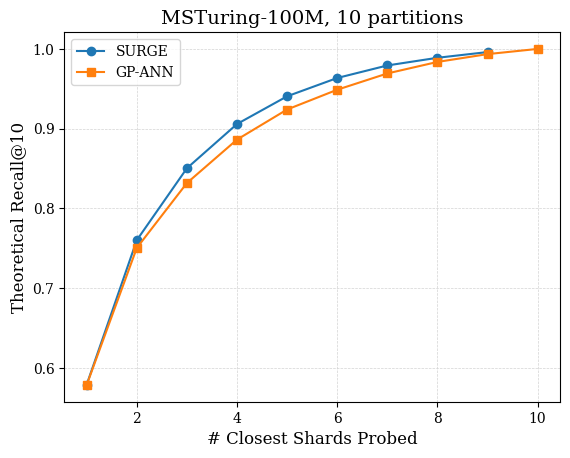

In [13]:
plt.plot(msturing_surge[msturing_surge["mode"] == "nprobe"]["param"],
         msturing_surge[msturing_surge["mode"] == "nprobe"]["recall"], label="SURGE",
         marker="o")
plt.plot(msturing_gpann["num_shards_searched"], 
         msturing_gpann["route_456_HNSW_HierKMeans"], label="GP-ANN", marker="s")

plt.xlabel("# Closest Shards Probed")
plt.ylabel("Theoretical Recall@10")
plt.title("MSTuring-100M, 10 partitions")
plt.legend()

plt.grid(True, which="both", linestyle="--", linewidth=0.5)


# save the figure
plt.savefig("msturing100_theoretical_recall_vs_nprobe.pdf", bbox_inches="tight")

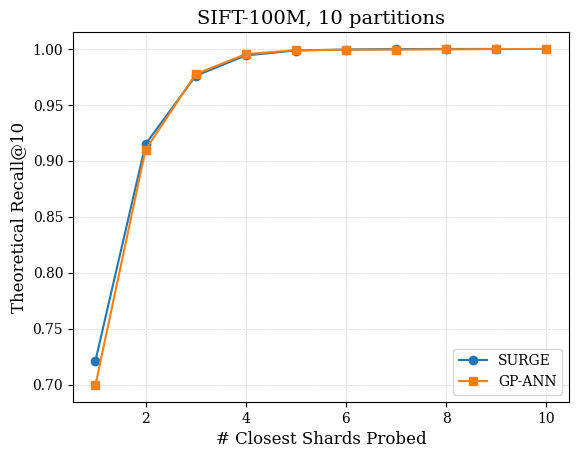

In [14]:
plt.plot(bigann_surge[bigann_surge["mode"] == "nprobe"]["param"],
         bigann_surge[bigann_surge["mode"] == "nprobe"]["recall"], label="SURGE", marker="o")
plt.plot(bigann_gpann["num_shards_searched"], 
         bigann_gpann["route_456_HNSW_HierKMeans"], label="GP-ANN", marker="s")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.xlabel("# Closest Shards Probed")
plt.ylabel("Theoretical Recall@10")
plt.title("SIFT-100M, 10 partitions")
plt.legend()
plt.savefig("sift100_theoretical_recall_vs_nprobe.pdf", bbox_inches="tight")

In [15]:
bigann_500M_surge_path = "/dataset/surge/results/theoretical_partition_quality_sift-500M_10_20260519_130459/routing_metrics.csv"
bigann_500M_surge = pd.read_csv(bigann_500M_surge_path)

msturing_500M_surge_path = "/dataset/surge/results/theoretical_partition_quality_msturing-500M_10_20260519_131044/routing_metrics.csv"
msturing_500M_surge = pd.read_csv(msturing_500M_surge_path)

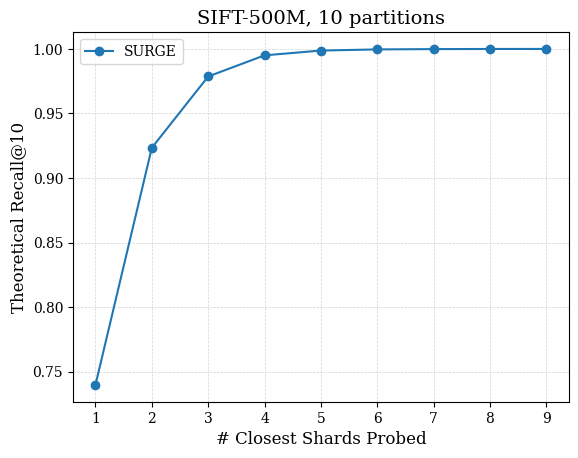

In [16]:
plt.plot(bigann_500M_surge[bigann_500M_surge["mode"] == "nprobe"]["param"],
         bigann_500M_surge[bigann_500M_surge["mode"] == "nprobe"]["recall"], label="SURGE", marker="o")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.xlabel("# Closest Shards Probed")
plt.ylabel("Theoretical Recall@10")
plt.title("SIFT-500M, 10 partitions")
plt.legend()
plt.savefig("sift500_theoretical_recall_vs_nprobe.pdf", bbox_inches="tight")

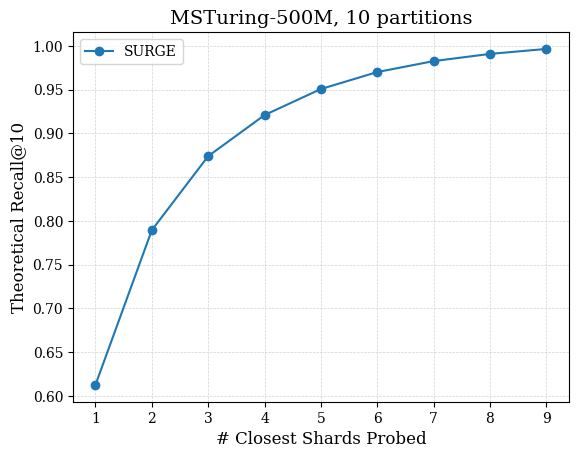

In [17]:
plt.plot(msturing_500M_surge[msturing_500M_surge["mode"] == "nprobe"]["param"],
         msturing_500M_surge[msturing_500M_surge["mode"] == "nprobe"]["recall"], label="SURGE", marker="o")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.xlabel("# Closest Shards Probed")
plt.ylabel("Theoretical Recall@10")
plt.title("MSTuring-500M, 10 partitions")
plt.legend()

plt.savefig("msturing500_theoretical_recall_vs_nprobe.pdf", bbox_inches="tight")